<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/labs/08_Survival_analysis_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages(c("survival", "survminer", "KMsurv"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘litedown’, ‘corrplot’, ‘car’, ‘markdown’, ‘png’, ‘jpeg’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘exactRankTests’, ‘mvtnorm’, ‘gridtext’, ‘ggpubr’, ‘gridExtra’, ‘maxstat’, ‘ggtext’




# Survival analysis using Kaplan-Meier method

## Prep

In this demo, we will use the data from Klein and Moeschberger - Survival Analysis. This data can be accessed using KMsurv package.

To download the package, do `install.packages("KMsurv")`. After downloading, look at the package contents and readme file by doing `library(help = KMsurv)`.

Also, download package called survminer in similar way to efficiently plot survival and coxph models.

## Getting data

For this part, we need packages `[1]"survival", "survminer", "KMsurv"` and their dependencies. Make sure all the dependencies are installed by trying to load the packages using `library()` function.

## About the data

Wagner and Altmann (1973) report data from a study conducted in the Amboseli Reserve in Kenya on the time of the day at which members of a baboon troop descend from the trees in which they sleep. The time is defined as the time at which half of the troop has descended and begun that day’s foraging. On some days the observers arrived at the site early enough to observe at what time this event occurred, whereas on other days they arrived after this median descent time, so that day’s observation was left censored at their arrival time. That data is in the following tables. By reversing the time scale to be the number of minutes from midnight (2400 hours), estimate the distribution of the time to descent for a randomly selected troop of baboons.

In [2]:
library(survival)
library(KMsurv)
library(tidyverse)
library(knitr)

data("baboon")
kable(head(baboon))
summary(baboon)
str(baboon)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors




|date     | time| observed|
|:--------|----:|--------:|
|25/11/63 |  656|        1|
|29/10/63 |  659|        1|
|5/11/63  |  720|        1|
|12/2/64  |  721|        1|
|29/3/64  |  743|        1|
|14/2/64  |  747|        1|

       date          time           observed     
 1/12/63 :  1   Min.   : 656.0   Min.   :0.0000  
 1/3/64  :  1   1st Qu.: 815.0   1st Qu.:0.0000  
 1/4/64  :  1   Median : 858.0   Median :0.0000  
 1/7/64  :  1   Mean   : 967.8   Mean   :0.3816  
 10/10/63:  1   3rd Qu.: 948.5   3rd Qu.:1.0000  
 10/3/64 :  1   Max.   :1829.0   Max.   :1.0000  
 (Other) :146                                    

'data.frame':	152 obs. of  3 variables:
 $ date    : Factor w/ 152 levels "1/12/63","1/3/64",..: 83 109 127 19 112 30 46 3 144 94 ...
 $ time    : int  656 659 720 721 743 747 750 751 754 758 ...
 $ observed: int  1 1 1 1 1 1 1 1 1 1 ...


Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




[1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [38] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [75] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[112] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[149] 0 0 0 0

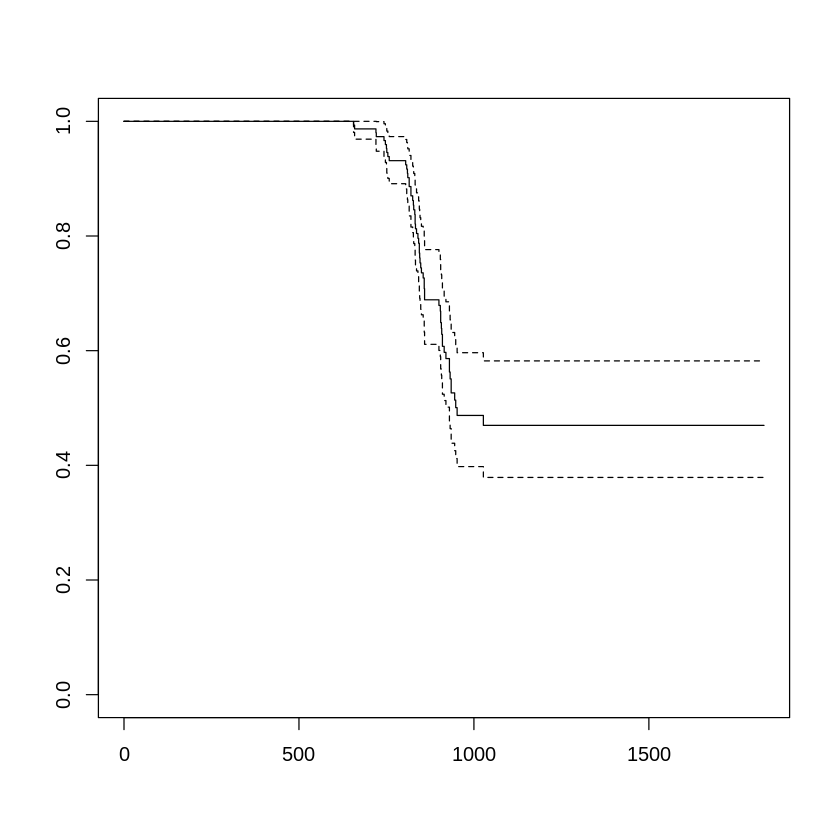

In [3]:
library(survminer)
surv_baboon <- Surv(time = baboon$time,
                    event = baboon$observed)
baboon$observed
plot(surv_baboon)

In [4]:
modsurv <- survfit(surv_baboon~1, data = baboon)
#surv_baboon is y variable

summary(modsurv)

Call: survfit(formula = surv_baboon ~ 1, data = baboon)

 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  656    152       1    0.993 0.00656        0.981        1.000
  659    151       1    0.987 0.00924        0.969        1.000
  720    147       1    0.980 0.01136        0.958        1.000
  721    144       1    0.973 0.01316        0.948        0.999
  743    141       1    0.966 0.01477        0.938        0.996
  747    140       1    0.960 0.01620        0.928        0.992
  750    139       1    0.953 0.01749        0.919        0.988
  751    136       1    0.946 0.01871        0.910        0.983
  754    134       1    0.939 0.01986        0.900        0.978
  758    131       1    0.931 0.02096        0.891        0.973
  805    129       1    0.924 0.02200        0.882        0.968
  808    124       1    0.917 0.02305        0.873        0.963
  810    123       1    0.909 0.02404        0.863        0.958
  811    121       1    0.902 0.02499        0.

Ignoring unknown labels:
• colour : "Strata"
Ignoring unknown labels:
• colour : "Strata"


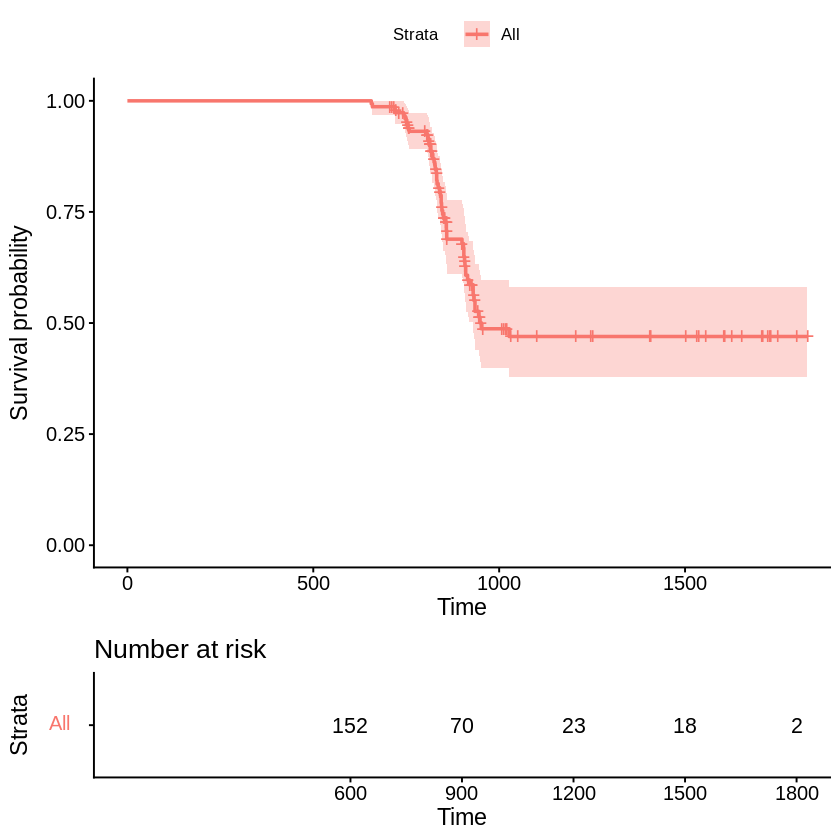

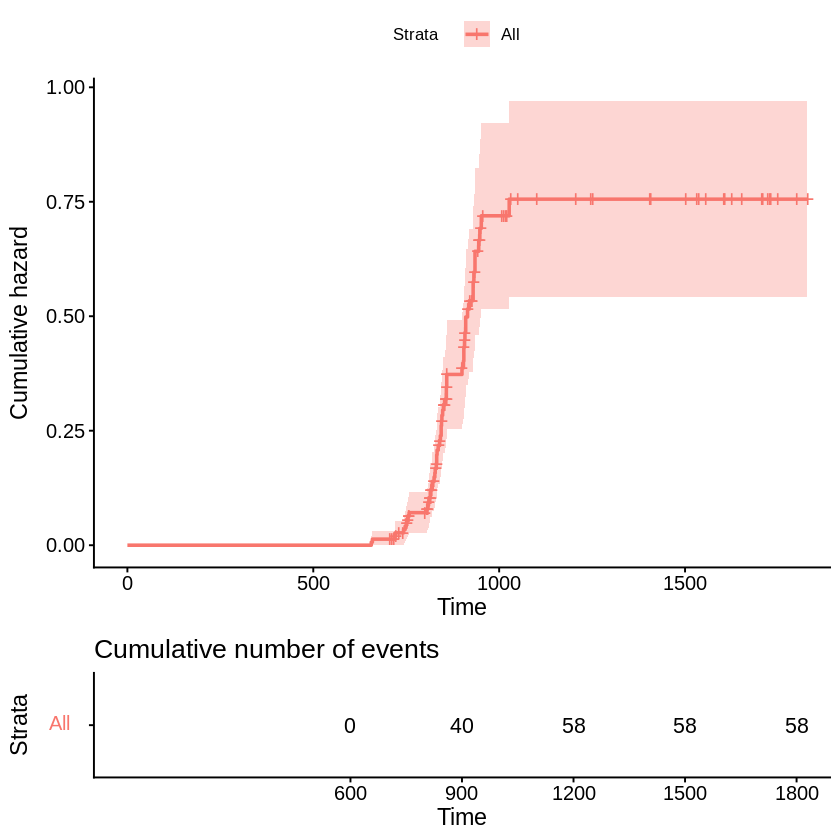

In [5]:
ggsurvplot(modsurv, risk.table = T)
ggsurvplot(modsurv, fun = "cumhaz", cumevents = T)

# Cox Proportional hazards

For this part, we need packages `[1]"survival", "survminer", "KMsurv"` and their dependencies. Make sure all the dependencies are installed by trying to load the packages using `library()` function.

## Load rats data

[Example 13.1 of K&M book]() Mantel et al. (1977) reports the results of a litter-matched study of the tumorigenesis of a drug. In the experiment, rats were taken from fifty distinct litters, and one rat of the litter was randomly selected and given the drug. For each litter, two rats were selected as controls and were given a placebo. All mice were females. Possible associations between litter mates in their times to development of tumors may be due to common genetic backgrounds shared by siblings. We shall test this hypothesis using the score test for association. The data is given in Table 13.1.

To perform the test, we first fit a Cox proportional hazards regression model to the data ignoring possible dependence between litter mates. A single covariate was used, which has the value 1 if the rat was in the treated group and 0 if the rat was in the placebo group


In [6]:
data("rats")

summary(rats)
str(rats)

      time            tumor             trt             litter    
 Min.   : 34.00   Min.   :0.0000   Min.   :0.0000   Min.   : 1.0  
 1st Qu.: 78.25   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:13.0  
 Median : 94.50   Median :0.0000   Median :0.0000   Median :25.5  
 Mean   : 89.45   Mean   :0.2667   Mean   :0.3333   Mean   :25.5  
 3rd Qu.:104.00   3rd Qu.:1.0000   3rd Qu.:1.0000   3rd Qu.:38.0  
 Max.   :104.00   Max.   :1.0000   Max.   :1.0000   Max.   :50.0  

'data.frame':	150 obs. of  4 variables:
 $ time  : int  101 104 104 77 89 88 104 96 82 70 ...
 $ tumor : int  0 0 0 0 0 1 1 1 0 1 ...
 $ trt   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ litter: int  1 2 3 4 5 6 7 8 9 10 ...


In [ ]:
#event collum is tumor

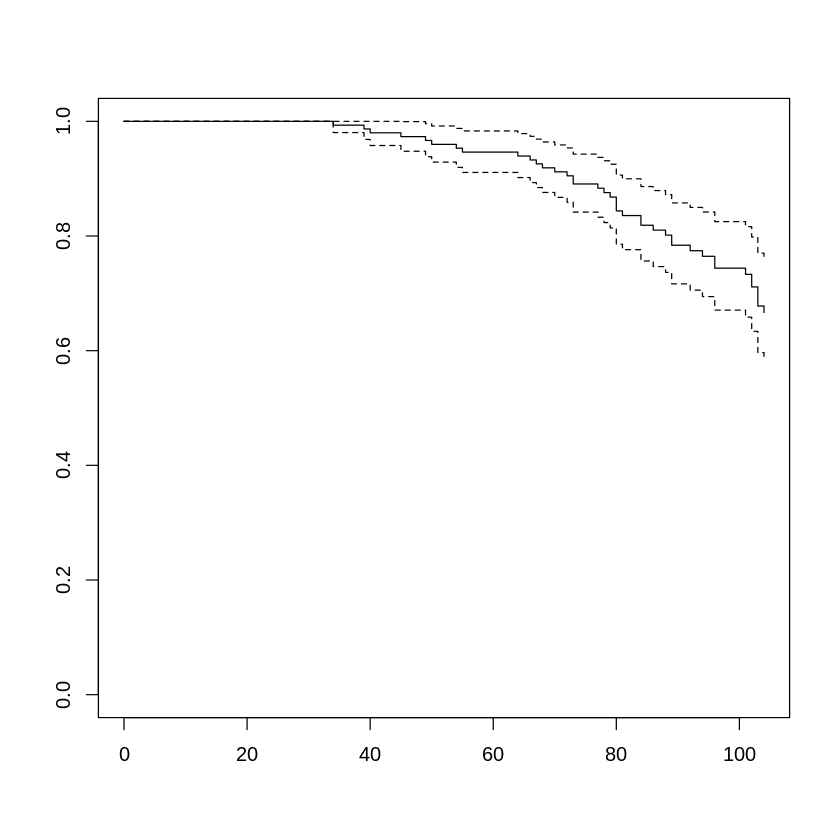

In [7]:
surv_rats = Surv(rats$time,event = rats$tumor)
surv_rats <- sort(surv_rats)
plot(surv_rats)

In [ ]:
#line in middle is estimte of survival
#other lines are CI

In [9]:
Summary(survfit(surv_rats~1))

ERROR: Error in (function (cond) : error in evaluating the argument 'x' in selecting a method for function 'Summary': argument "data" is missing, with no default


In [22]:
surv_rats <- Surv(time = rats$time, event = rats$tumor)
#mod_ph <- coxph(surv_rats ~ trt, data = rats)
#mod_ph1 <- coxph(surv_rats ~ trt + litter, data = rats)
mod_ph2 <- coxph(surv_rats ~ trt, data = rats, weights = rats$litter)
#mod_ph3 <- coxph(surv_rats ~ trt, data = rats, cluster = rats$litter)


summary(mod_ph1)

Call:
coxph(formula = surv_rats ~ trt + litter, data = rats)

  n= 150, number of events= 40 

          coef exp(coef) se(coef)     z Pr(>|z|)   
trt    0.91767   2.50344  0.31759 2.889  0.00386 **
litter 0.01437   1.01447  0.01089 1.319  0.18708   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

       exp(coef) exp(-coef) lower .95 upper .95
trt        2.503     0.3994     1.343     4.665
litter     1.014     0.9857     0.993     1.036

Concordance= 0.609  (se = 0.048 )
Likelihood ratio test= 9.73  on 2 df,   p=0.008
Wald test            = 9.86  on 2 df,   p=0.007
Score (logrank) test = 10.43  on 2 df,   p=0.005


In [ ]:
#2.5 means hazards trx group or 2.5x increase for the trx group

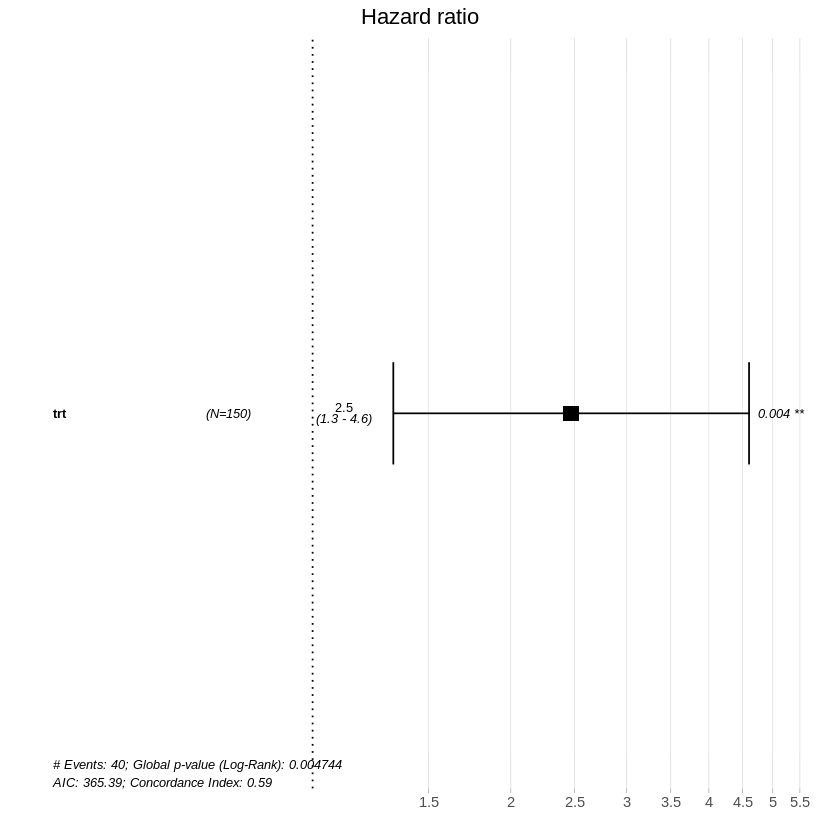

In [23]:
ggforest(mod_ph, data = rats)

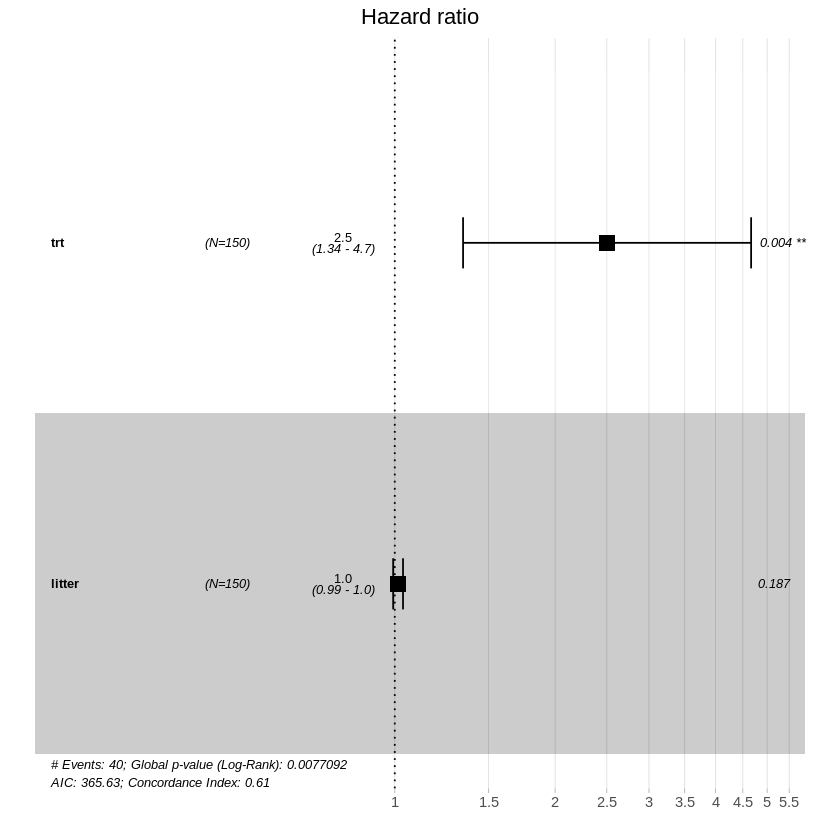

In [24]:
ggforest(mod_ph1, data = rats)
# ggforest(mod_ph2, data = rats)
# ggforest(mod_ph3, data = rats)

In [25]:
anova(mod_ph, mod_ph1, mod_ph2)

,loglik,Chisq,Df,Pr(>|Chi|)
,<dbl>,<dbl>,<int>,<dbl>
1,-181.6949,NA,NA,NA
2,-180.8168,1.756131,1,0.1851078
3,-8687.5348,17013.435940,1,0.0000000


## Check diagnostics

In [ ]:
#check assumptions --> independence

In [28]:
cox.zph(mod_ph) # look out for p-value below 0.05
cox.zph(mod_ph1)

       chisq df     p
trt     5.02  1 0.025
GLOBAL  5.02  1 0.025

       chisq df     p
trt    4.966  1 0.026
litter 0.393  1 0.531
GLOBAL 5.388  2 0.068

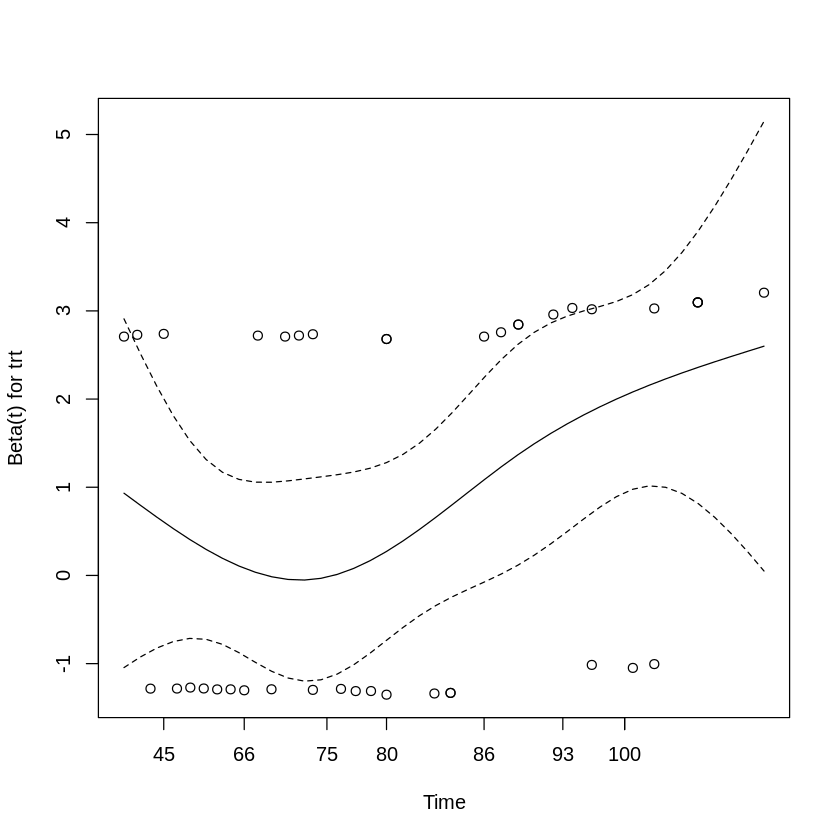

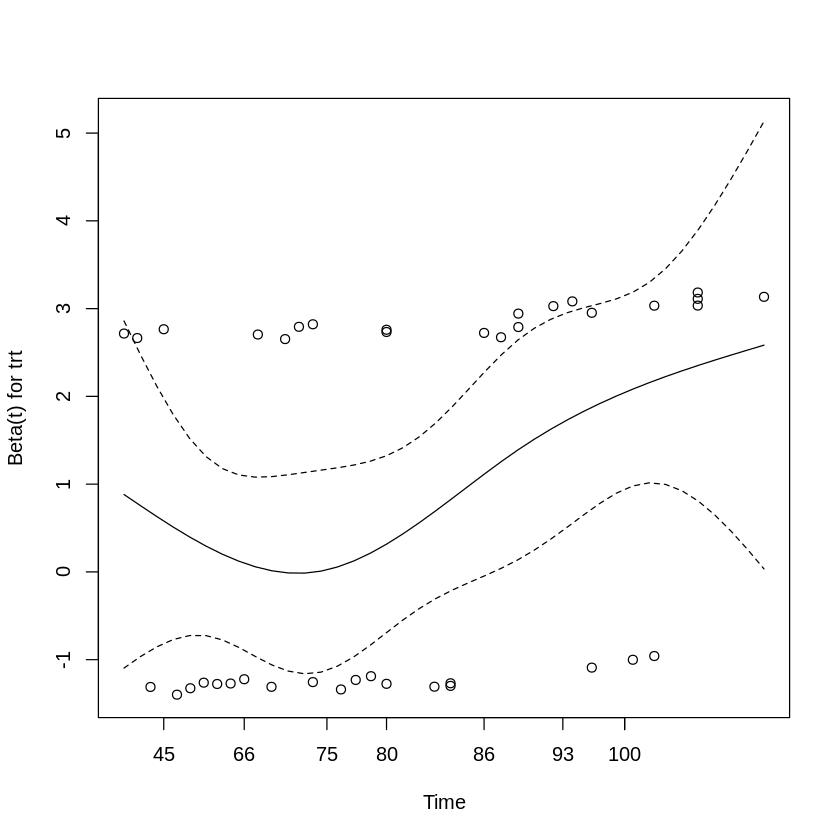

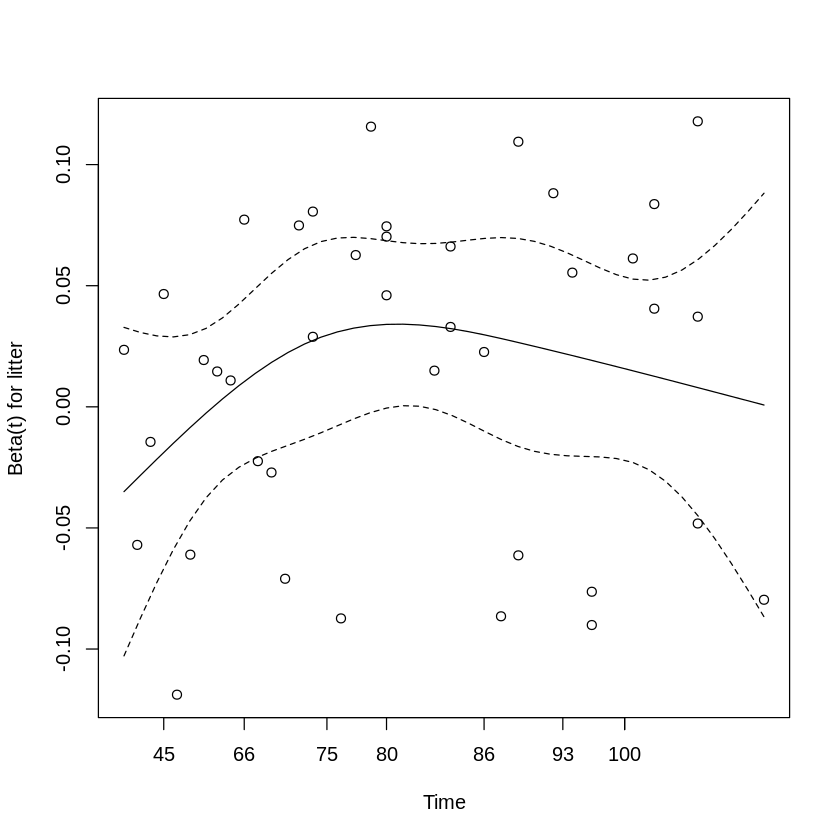

In [29]:
plot(cox.zph(mod_ph)) # Look for non-horizontal pattern
plot(cox.zph(mod_ph1)) # Look for non-horizontal pattern


In [ ]:
#line in middle is beta
#second and thrid graph violates cox
#use cox model to see if it violated

## Survival curves of Cox PH model

We can easily convert the `coxph()`derived model into KM curves by using the following code

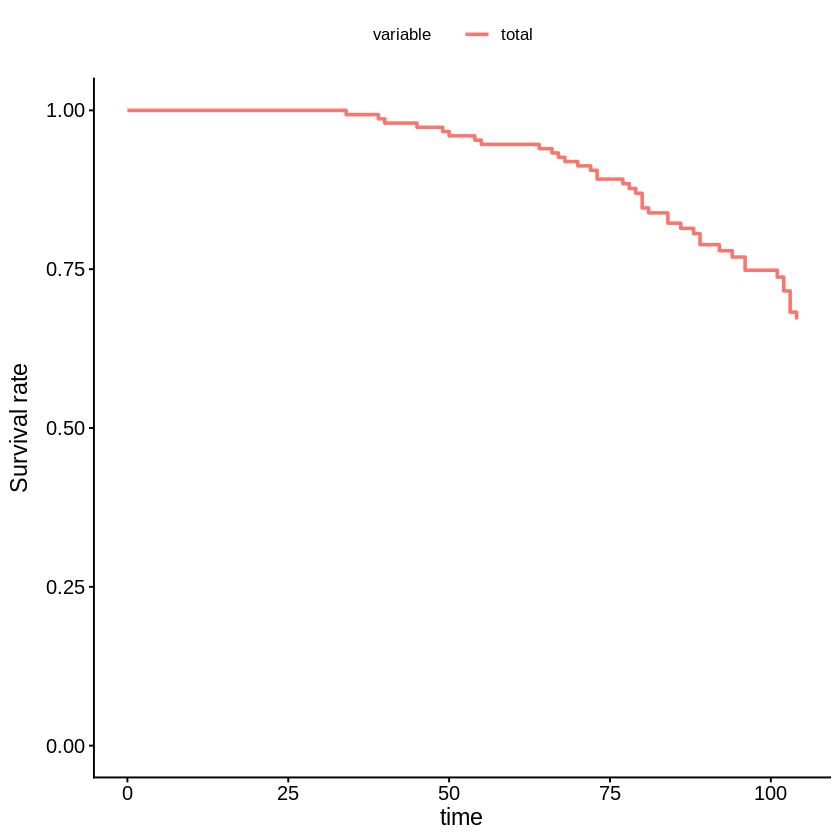

In [30]:
surv_ph <- surv_adjustedcurves(mod_ph, data = rats)
ggadjustedcurves(mod_ph, data = rats)

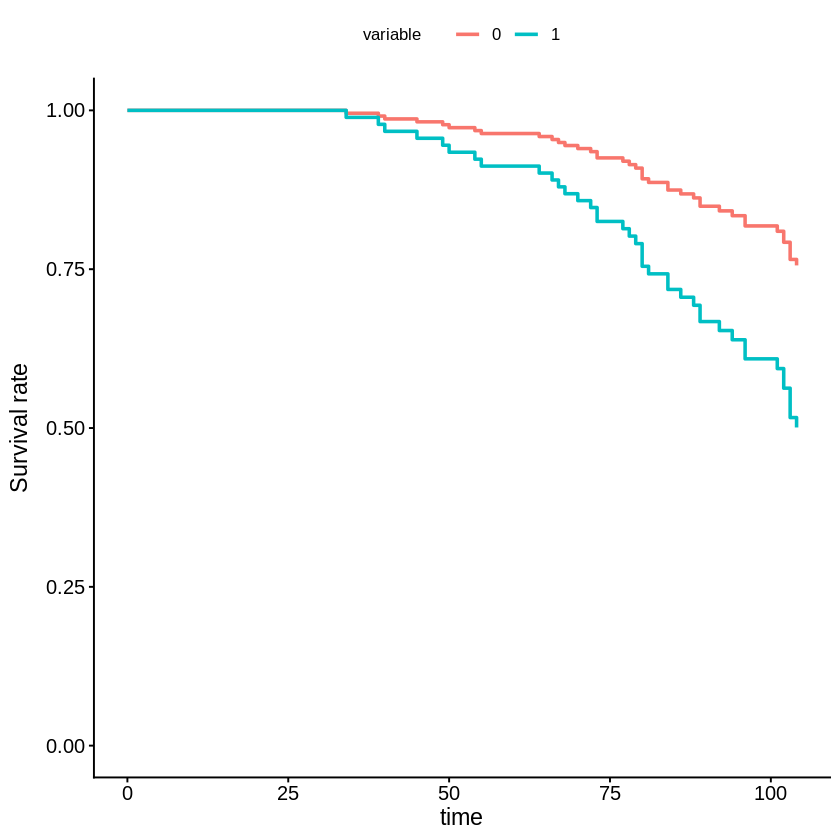

In [31]:
ggadjustedcurves(mod_ph, data = rats, method = "average", variable = "trt")

# Survival analysis using Kaplan-Meier method

## Analysis with censoring present.

In this demonstration, we will use a dataset from `survival` package.
This data is called `colon` or `cancer` or one nested in the other
depending on the version of survival package you use.

### Background

Freireich et al. (1963) report the results of a clinical trial of a drug
6-mercaptopurine (6-MP) versus a placebo in 42 children with acute
leukemia. The trial was conducted at 11 American hospitals. Patients
were selected who had a complete or partial remission of their leukemia
induced by treatment with the drug prednisone. (A complete or partial
remission means that either most or all signs of disease had disappeared
from the bone marrow.) The trial was conducted by matching pairs of
patients at a given hospital by remission status (complete or partial)
and randomizing within the pair to either a 6-MP or placebo maintenance
therapy. Patients were followed until their leukemia returned (relapse)
or until the end of the study (in months).

This data frame contains the following columns: - pair pair number -
remstat Remission status at randomization (1=partial, 2=complete) - t1
Time to relapse for placebo patients, months - t2 Time to relapse for
6-MP patients, months - relapse Relapse indicator (0=censored,
1=relapse) for 6-MP patients


- [link](https://cran.r-project.org/web/packages/KMsurv/KMsurv.pdf)


In [ ]:
data("drug6mp")
kable(drug6mp, align = "c")

In [ ]:
df <- pivot_longer(drug6mp, cols = t1:t2, names_to = "treatment", values_to = "stime")
df <- mutate(df, stime = as.numeric(stime))
kable(df, align = "c")

In [ ]:
so <- Surv(time = df$stime, event = df$relapse)
plot(so)

In [ ]:
ggsurvevents(so,type = "cumulative")

In [ ]:
modsurv1 <- survfit(so ~ 1, data = df, na.action = na.omit)
modsurv2 <- survfit(so ~ treatment, data = df, na.action = na.omit)
summary(modsurv1)

In [ ]:
summary(modsurv2)

In [ ]:
ggsurvplot(modsurv1,cumcensor = T, cumevents = T, risk.table = T)

In [ ]:
ggsurvplot(modsurv2,cumcensor = T, cumevents = T, risk.table = T)

In [ ]:
modsurv3 <- coxph(so~treatment, data = df)
ggforest(modsurv3, data = df)

In [ ]:
modsurv4 <- survreg(so~treatment, data = df,
                    dist = "lognormal",
                    scale = 0, score = T)
summary(modsurv4)

In [ ]:
modsurv5 <- survreg(so~treatment, data = df,
                    dist = "loglogistic",
                    scale = 0, score = T)
summary(modsurv5)

In [ ]:
modsurv6 <- survreg(so~treatment, data = df,
                    dist = "exponential",
                    score = T)
summary(modsurv6)

In [ ]:
modsurv7 <- survreg(so~treatment, data = df,
                    dist = "weibull", scale = 0,
                    score = T)
summary(modsurv7)

In [ ]:
anova(modsurv4,modsurv5,modsurv6,modsurv7)

In [ ]:
kable(data.frame(Model_name = c("modsurv4", "modsurv5",
                                "modsurv6", "modsurv7"),
                Formulas = c(deparse(formula(modsurv4)),
                             deparse(formula(modsurv5)),
                             deparse(formula(modsurv6)),
                             deparse(formula(modsurv7))),
                Time_distr = c("lognormal", "loglogistic",
                               "exponential", "weibull"),
                AIC = c(AIC(modsurv4),AIC(modsurv5),
                        AIC(modsurv6), AIC(modsurv7))),
      digits = 3)

### Challenge: Try fitting the same functions for `df$remstat` as event variable